In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<span style="font-size: 40px; font-weight: bold;">Loading Dataset</span>

In [208]:
df=pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<span style="font-size: 30px; font-weight: bold;"> Analysing the data with count and null values</span>

In [209]:
print(df.info())

display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [210]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [211]:
print("shape= ",df.shape)
print(df.isnull().sum())

shape=  (167, 10)
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


<span style="font-size: 15px; "> 0 Null Values in the data set</span>

In [212]:
df.duplicated().sum()

0

<span style="font-size: 30px; font-weight: bold;">EDA</span>

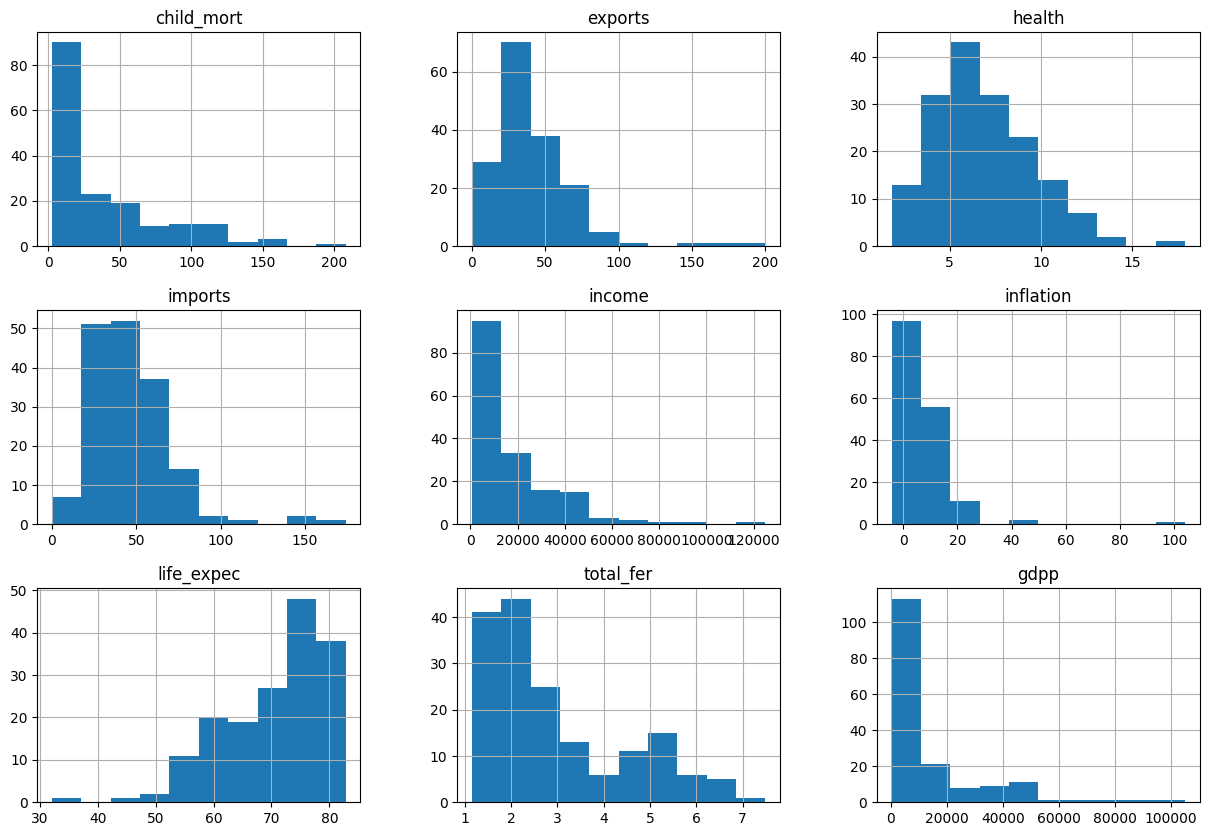

In [213]:
df.hist(figsize=(15,10))
plt.show()

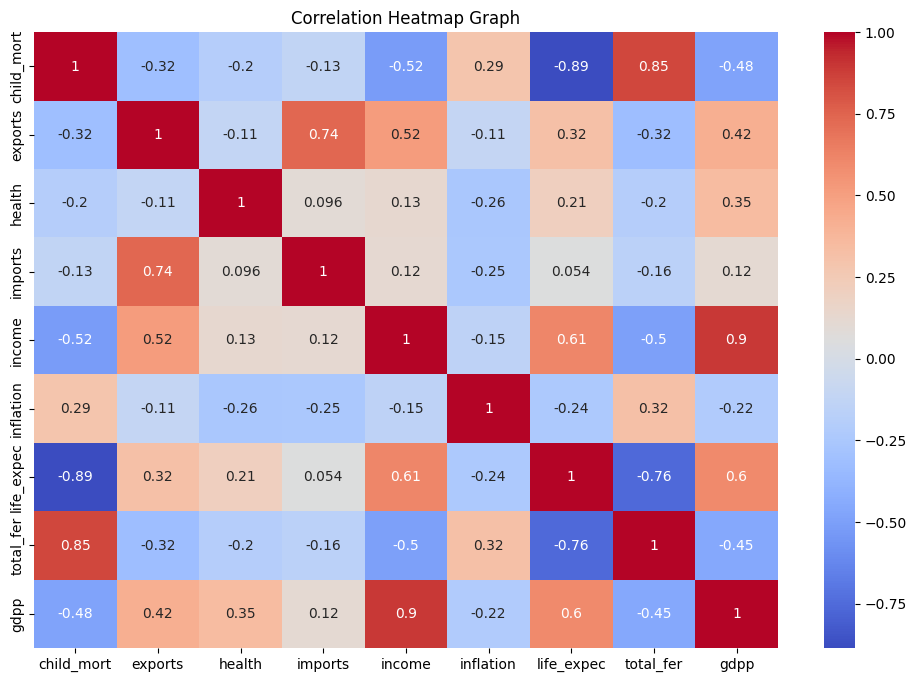

In [214]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap Graph')
plt.show()

<span style="font-size: 15px; "> 1) Income and GDP (gdpp) show strong positive correlation that means richer countries have higher GDP per capita.</span><BR>
<span style="font-size: 15px; ">
2) Child mortality is negatively correlated with life expectancy => higher deaths in poorer countries.</span>

<span style="font-size: 20px; "> Outliers Visualization</span>

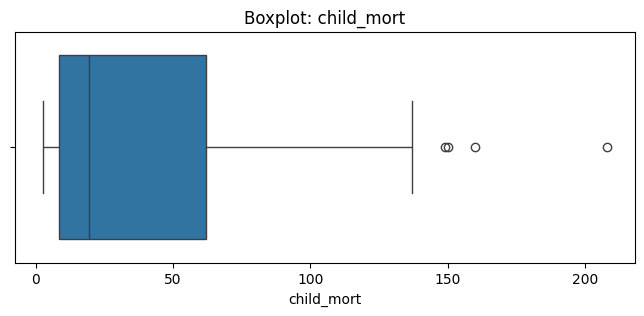

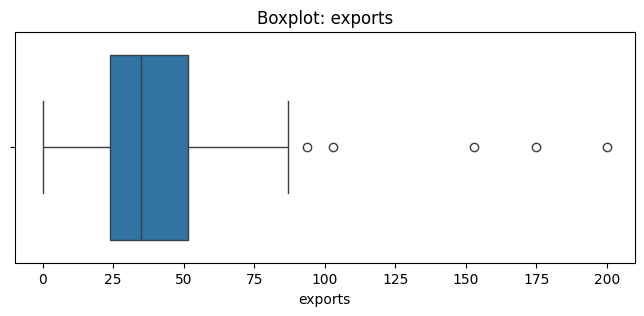

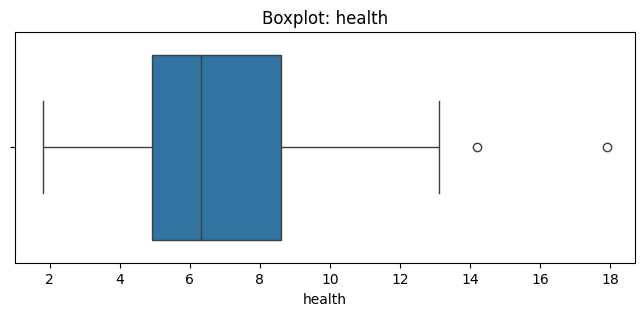

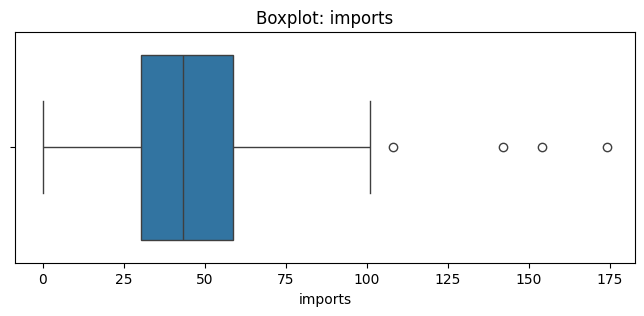

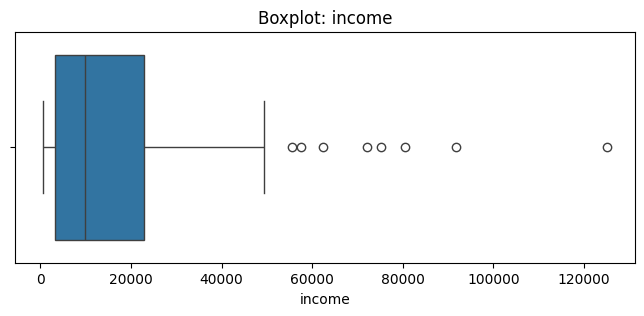

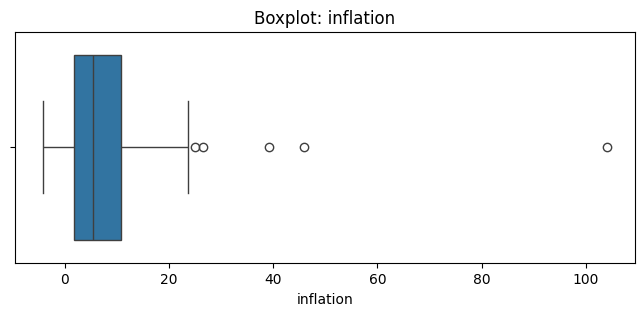

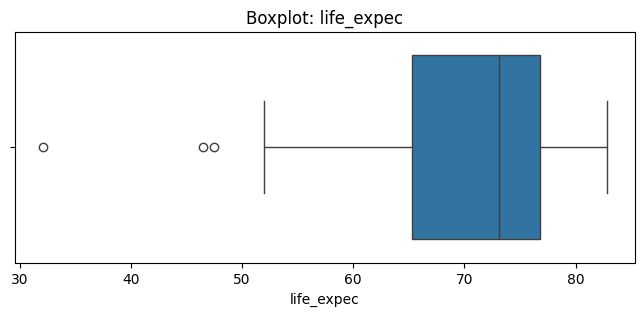

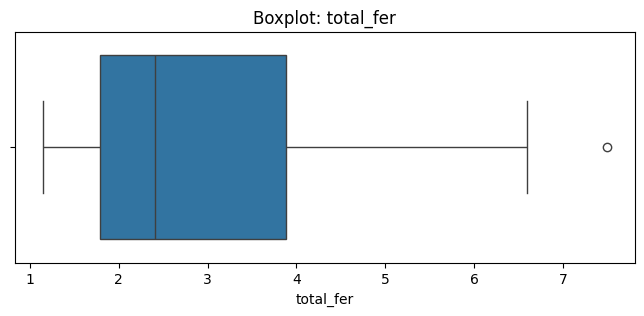

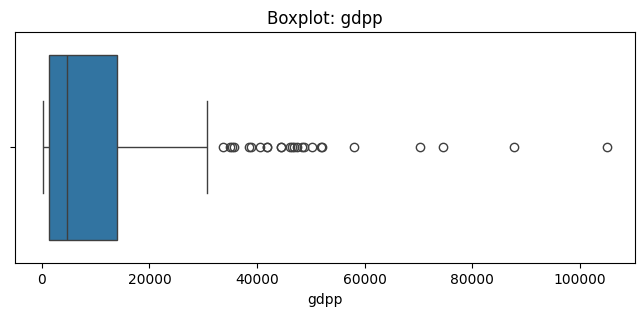

In [215]:
numeric_cols=df.drop("country", axis=1)
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

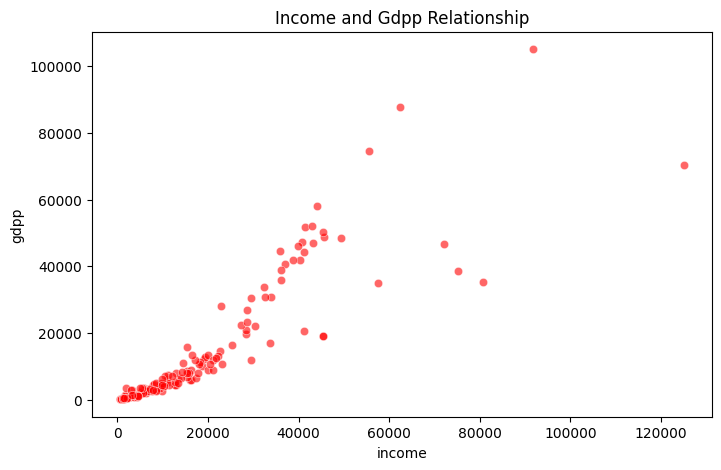

In [216]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='income', y='gdpp', alpha=0.6, color='red')
plt.title('Income and Gdpp Relationship')
plt.xlabel('income')
plt.ylabel('gdpp')
plt.show()

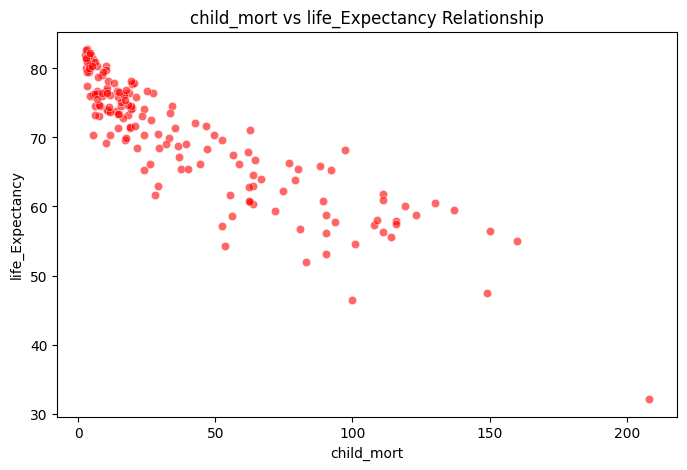

In [217]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='child_mort', y='life_expec', alpha=0.6, color='red')
plt.title('child_mort vs life_Expectancy Relationship')
plt.xlabel('child_mort')
plt.ylabel('life_Expectancy')
plt.show()

In [218]:
from sklearn.preprocessing import StandardScaler
features = df.drop(columns=['country'], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled.shape

(167, 9)

In [219]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
print("clusters = ",wcss)

clusters =  [1503.0, 1050.2145582853307, 831.4244352086876, 700.5205369722204, 620.1633712888422, 558.4696598590401, 495.80794552153463, 457.58614789124226, 427.8036719813467, 403.22961251364364]


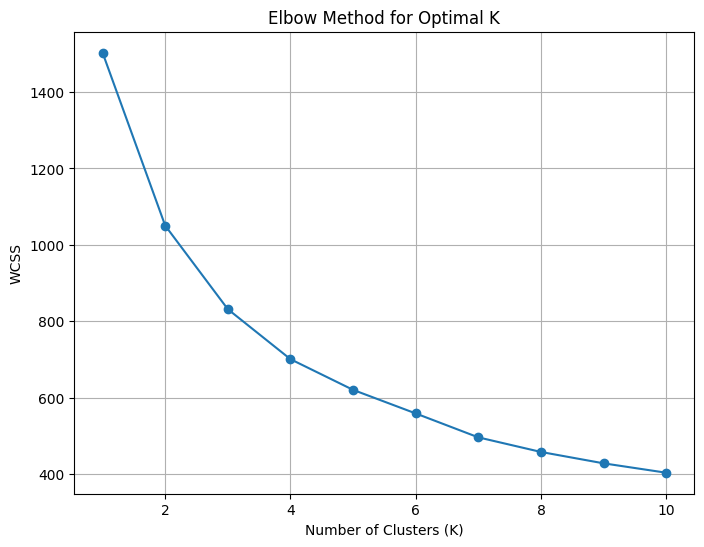

In [220]:
plt.figure(figsize=(8,6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid()
plt.show()

<span style="font-size: 15px; "> Notice that:
<Br> From K=1 → K=2, there is a huge improvement.
<Br>
From K=2 → K=3, there is still a substantial improvement.<Br>
From K=3 → K=4, the improvement is noticeable.<Br>
After K=4, the curve starts flattening significantly.

</span>



In [221]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


<span style="font-size: 20px; "> Cluster Value Counts </span>

In [222]:
df["Cluster"].value_counts().sort_index()

Cluster
0    36
1    47
2    84
Name: count, dtype: int64

In [223]:
cluster_analysis = df.groupby("Cluster").mean(numeric_only=True)
cluster_analysis

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


<span style="font-size: 15px; "> 
Here we can see for Cluster 0:<BR>
Child Mortality = LOW<BR>
Income = HIGH<Br>
Life Expectancy = HIGH<BR>
GDP = HIGH<BR>
Now same for other clusters 
<BR>

<Br>0 = Developed<BR>
1 = Underdeveloped<BR>
2 = Developing<BR>


</span>



In [224]:
cluster_names = { 0: "Developed", 1: "Underdeveloped", 2: "Developing" }

df["Country_Category"] = df["Cluster"].map(cluster_names)

df[["country", "Cluster", "Country_Category"]].head(8)

,country,Cluster,Country_Category
0,Afghanistan,1,Underdeveloped
1,Albania,2,Developing
2,Algeria,2,Developing
3,Angola,1,Underdeveloped
4,Antigua and Barbuda,2,Developing
5,Argentina,2,Developing
6,Armenia,2,Developing
7,Australia,0,Developed


<span style="font-size: 20px; "> PCA Visualization</span>

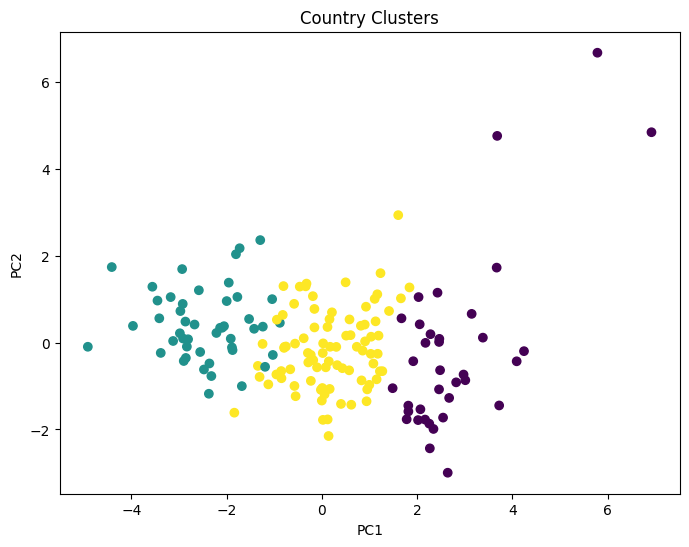

In [225]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter( X_pca[:,0], X_pca[:,1], c=df['Cluster'] )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Country Clusters")
plt.show()

<span style="font-size: 30px; font-weight: bold;">Train-Test and Split</span>

In [226]:
from sklearn.model_selection import train_test_split

X = df.drop(["country", "Cluster", "Country_Category"], axis=1)
y = df["Cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



<span style="font-size: 30px; font-weight: bold;">Random Forest Classification</span>

In [227]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



<span style="font-size: 30px; font-weight: bold;">XGBoost Classification</span>

In [228]:
from xgboost import XGBClassifier

xgb = XGBClassifier( n_estimators=100, random_state=42, eval_metric='mlogloss')

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.9411764705882353

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      0.90      0.95        10
           2       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



<span style="font-size: 30px; font-weight: bold;">DBSCAN Clustering</span>

In [229]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


<span style="font-size: 20px; "> DBSCAN does not require the number of clusters to be specified in advance and is capable of detecting noise and outliers in the dataset."</span>

In [230]:
print("Number of DBSCAN Clusters:", len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0))

print("Number of Noise Points:", list(df['DBSCAN_Cluster']).count(-1))

Number of DBSCAN Clusters: 1
Number of Noise Points: 30


<span style="font-size: 20px; "> DBSCAN Clusters</span>

In [231]:
dbscan = DBSCAN(eps=1.2, min_samples=3)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 1    78
-1    41
 0    25
 2    19
 3     4
Name: count, dtype: int64


<span style="font-size: 30px; font-weight: bold;"> Feature importance</span>

In [232]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

      Feature  Importance
0  child_mort    0.258356
8        gdpp    0.197672
7   total_fer    0.174131
6  life_expec    0.166180
4      income    0.144466
2      health    0.025791
5   inflation    0.016371
3     imports    0.009472
1     exports    0.007561


<span style="font-size: 20px; "> Visualization</span>

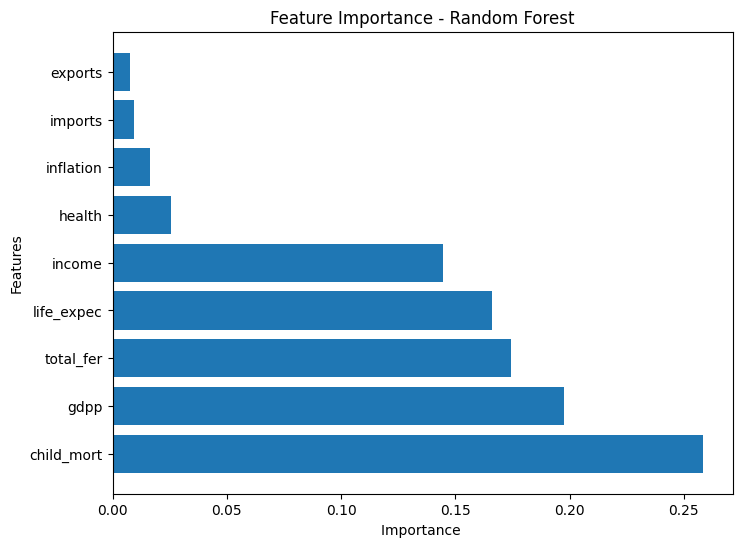

In [233]:
plt.figure(figsize=(8,6))

plt.barh( importance['Feature'], importance['Importance'] )

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance ")
plt.ylabel("Features")

plt.show()

<span style="font-size: 20px; "> The visualization highlights the relative contribution of each socio-economic indicator in determining country segments and provides interpretability to the classification model.</span>

<span style="font-size: 30px; font-weight: bold;">Model Comparison</span>

performance of Random Forest and XGBoost classifiers was compared using accuracy scores.

In [234]:
from sklearn.metrics import accuracy_score

rf_acc = accuracy_score(y_test, y_pred)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print("Random Forest Accuracy :", rf_acc)
print("XGBoost Accuracy :", xgb_acc)

Random Forest Accuracy : 1.0
XGBoost Accuracy : 0.9411764705882353


In [235]:
forecast = pd.DataFrame({'Actual':y_test.values,'Predicted':y_pred})

forecast['Error_%'] = ( abs(forecast['Actual']-forecast['Predicted']) / forecast['Actual'] ) * 100

forecast.sample(20)

,Actual,Predicted,Error_%
14,1,1,0.0
20,2,2,0.0
22,0,0,NaN
19,2,2,0.0
1,1,1,0.0
12,2,2,0.0
18,1,1,0.0
25,2,2,0.0
5,2,2,0.0
0,2,2,0.0


<span style="font-size: 30px; font-weight: bold;">Conclusion</span>

<span style="font-size: 15px; "> This project successfully applied K-Means and DBSCAN clustering techniques to categorize countries based on socio-economic and health indicators. The generated cluster labels were further used to train Random Forest and XGBoost models, achieving high predictive performance, with <b>Random Forest obtaining 100% accuracy and XGBoost achieving 94.12% accuracy.</B> Feature importance analysis identified child mortality, GDP per capita, income, fertility rate, and life expectancy as the most influential factors affecting country development.

Overall, the project demonstrates how the combination of unsupervised and supervised machine learning techniques can transform unlabeled socio-economic data into meaningful country segments and provide actionable insights. These findings can help organizations like HELP International make data-driven decisions and strategically allocate humanitarian aid to countries that require the most support..</span>